# MDR-TS v1.4
**Temporal-Station Baseline Model for Soil Moisture Prediction**

**Author:** Jakob Balkovec  
**Affiliation:** Seattle University, Computer Science  
**Project:** MDR
**Notebook Type:** Training & Evaluation  
**Last Updated:** Tue Jan 6th 2026

---

## Model Summary
- **Model Name:** MDR-TS  
- **Version:** v1.2
- **Task:** Regression (Soil Moisture at 5 cm depth)  
- **Target Variable:** `soil_moisture_5cm`  
- **Temporal Resolution:** Daily  

---

## Reproducibility
- **Random Seed:** 42
- **Split Metadata:** `data/splits/derived_8.0/split_meta.json`
- **Environment:** Google Colab / VS Code Remote Kernel

---

Adapted for a Macbook M2 Pro environment.

**What's new?**

- Adding weights to improve spatial generalization

## 0. Imports

In [1]:
import os
import sys
import random
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance

import torch

project_root = os.path.abspath("../../")
if project_root not in sys.path:
    sys.path.append(project_root)

from Utils.dashboard import metrics_dashboard

import warnings
warnings.filterwarnings("ignore")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("imports loaded")
print(f"using: {device}")

def rmse(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return float(np.sqrt(np.mean((y_pred - y_true) ** 2)))

def assign_regime(sm):
    if sm < 0.20:
        return 'D'
    elif sm < 0.313:
        return 'T'
    else:
        return 'W'

imports loaded
using: cpu


In [2]:
SEED = 42
DEEP_SEARCH = 40

random.seed(SEED)
np.random.seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)

print(f"Random seed set to {SEED}")

def print_env_info():
    print("Environment information:")
    print(f"  Python version: {os.sys.version.split()[0]}")
    print(f"  NumPy version:  {np.__version__}")
    print(f"  Pandas version: {pd.__version__}")

    try:
        import xgboost
        print(f"  XGBoost version: {xgboost.__version__}")
    except ImportError:
        print("  XGBoost not installed")

    IN_COLAB = "COLAB_GPU" in os.environ
    print(f"  Running in Colab: {IN_COLAB}")

    if IN_COLAB:
        gpu = os.environ.get("COLAB_GPU", None)
        print(f"  GPU available: {gpu}")
    else:
        print("  GPU available: False")

print_env_info()

plt.style.use("default")
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True

print("environment setup complete")

Random seed set to 42
Environment information:
  Python version: 3.10.18
  NumPy version:  1.26.4
  Pandas version: 2.0.3
  XGBoost version: 3.2.0
  Running in Colab: False
  GPU available: False
environment setup complete


In [3]:
VERSION = "v1.2"
SUBVERSION = "v1.2"
RUN_NAME = "mdr_ts_v1.2"

PROJECT_ROOT = "/Users/jbalkovec/Desktop/MDR"
DATA_ROOT = f"{PROJECT_ROOT}/Temporal/Pipeline/data"
SPLIT_ROOT = f"{DATA_ROOT}/splits"
OUTPUT_ROOT = f"{PROJECT_ROOT}/Models/Temporal/{VERSION}/{SUBVERSION}"

os.makedirs(OUTPUT_ROOT, exist_ok=True)

print("Project paths:")
print(f"  PROJECT_ROOT: {PROJECT_ROOT}")
print(f"  DATA_ROOT:    {DATA_ROOT}")
print(f"  SPLIT_ROOT:   {SPLIT_ROOT}")
print(f"  OUTPUT_ROOT:  {OUTPUT_ROOT}")

print("\nKey file checks:")
print("  data exists:",
      os.path.exists(DATA_ROOT))
print("  splits exists:",
      os.path.exists(SPLIT_ROOT))
print("  output exists:",
      os.path.exists(OUTPUT_ROOT))

Project paths:
  PROJECT_ROOT: /Users/jbalkovec/Desktop/MDR
  DATA_ROOT:    /Users/jbalkovec/Desktop/MDR/Temporal/Pipeline/data
  SPLIT_ROOT:   /Users/jbalkovec/Desktop/MDR/Temporal/Pipeline/data/splits
  OUTPUT_ROOT:  /Users/jbalkovec/Desktop/MDR/Models/Temporal/v1.2/v1.2

Key file checks:
  data exists: True
  splits exists: True
  output exists: True


In [4]:
TRAIN_PATH = str(Path(SPLIT_ROOT) / "derived_8.0/train.csv")
VAL_PATH   = str(Path(SPLIT_ROOT) / "derived_8.0/val.csv")
TEST_PATH  = str(Path(SPLIT_ROOT) / "derived_8.0/test.csv")

for p in [TRAIN_PATH, VAL_PATH, TEST_PATH]:
    if not os.path.exists(p):
        raise FileNotFoundError(f"Missing split file: {p}")

print("Split files:")
print(" ", TRAIN_PATH)
print(" ", VAL_PATH)
print(" ", TEST_PATH)

train_df = pd.read_csv(TRAIN_PATH)
val_df   = pd.read_csv(VAL_PATH)
test_df  = pd.read_csv(TEST_PATH)

Split files:
  /Users/jbalkovec/Desktop/MDR/Temporal/Pipeline/data/splits/derived_8.0/train.csv
  /Users/jbalkovec/Desktop/MDR/Temporal/Pipeline/data/splits/derived_8.0/val.csv
  /Users/jbalkovec/Desktop/MDR/Temporal/Pipeline/data/splits/derived_8.0/test.csv


In [5]:
print("Common columns across splits:",
      len(set(train_df.columns) & set(val_df.columns) & set(test_df.columns)))

print("\ncolumns:")
print(list(train_df.columns)[:30])

Common columns across splits: 499

columns:
['station_id', 'date', 'longitude', 'latitude', 'precip_mm', 's1_vv', 's1_vh', 's2_b4', 's2_b8', 's2_b11', 's2_b12', 'LST_modis', 'elev', 'slope', 'aspect', 'DOY', 'SMAP_sm_am_interp', 'SMAP_sm_pm_interp', 'soil_moisture_5cm', 'J_aspect_deg', 'J_bio_bio01', 'J_bio_bio02', 'J_bio_bio03', 'J_bio_bio04', 'J_bio_bio05', 'J_bio_bio06', 'J_bio_bio07', 'J_bio_bio08', 'J_bio_bio09', 'J_bio_bio10']


In [6]:
TARGET_COL = "soil_moisture_5cm"

KEEP_META_COLS = ["station_id", "date", "longitude", "latitude"]

FEATURE_COLS = [
    'SMAP_sm_pm_interp_ema02',
    'V_rollmin_LST_modis_kobs30',
    'D_sin_DOY', 'G_rain_sum_3d',
    'V_rollmin_G_API_kobs30',
    'G_rain_sum_7d',
    'C_lag_LST_modis_kobs30',
    'C_lag_G_API_kobs1',
    'V_ema_G_API_kobs14',
    'V_rollmean_G_API_kobs14',
    'G_API', 'G_DSLR',
    'SMAP_ampm_diff_interp',
    'V_rollmax_G_API_kobs30',
    'V_ema_G_API_kobs30',
    'V_rollmean_s2_b11_kobs7',
    'V_ema_LST_modis_kobs7',
    'V_rollmean_G_API_kobs7',
    'C_lag_s2_b11_kobs30',
    'A_d_E_SAR_diff_kobs14',
    'C_lag_LST_modis_kobs6',
    'A_d_LST_modis_kobs14',
    'A_d_SMAP_sm_interp_kobs14',
    'V_rollstd_SMAP_sm_interp_kobs30',
    'SMAP_sm_interp_grad7',
    'year_frac', 'sin_year', 'cos_year',
    'API_x_year', 'SMAP_x_year',
    'slope', 'elev', 'K_slope_sin',
    'K_slope_cos', 'K_aspect_cos',
    'J_clay_wfrac_b0', 'J_sand_wfrac_b0'
    ]

### Interaction Features

In [7]:
corr = train_df[FEATURE_COLS].corr().abs()
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))

high_corr = upper.stack()
high_corr = high_corr[high_corr > 0.995]

if high_corr.empty:
    print("No highly correlated pairs found")
else:
    print("Highly correlated pairs:")
    for (col, row), val in high_corr.items():
        print(f"{col} <-> {row} : {val:.5f}")

No highly correlated pairs found


In [8]:
def get_metrics_dict(y_true, y_pred, prefix=""):
    y_true = np.asarray(y_true).ravel()
    y_pred = np.asarray(y_pred).ravel()

    err = y_true - y_pred
    ae = np.abs(err)

    r2 = float(r2_score(y_true, y_pred))
    mae = float(mean_absolute_error(y_true, y_pred))
    rmse = float(root_mean_squared_error(y_true, y_pred))

    bias = float(np.mean(err))
    ubrmse = float(np.std(err))

    q_err = np.quantile(err, [0.05, 0.25, 0.50, 0.75, 0.95])

    return {
        f"{prefix}n": int(len(y_true)),
        f"{prefix}r2": r2,
        f"{prefix}mae": mae,
        f"{prefix}rmse": rmse,
        f"{prefix}ubrmse": ubrmse,
        f"{prefix}bias": bias,
        f"{prefix}med_ae": float(np.median(ae)),
        f"{prefix}p90_ae": float(np.quantile(ae, 0.90)),
        f"{prefix}q05_err": float(q_err[0]),
        f"{prefix}q50_err": float(q_err[2]),
        f"{prefix}q95_err": float(q_err[4]),
    }

def neat_print(metrics):
    print(f"{'METRIC':<15} | {'VALUE':<10}")
    print("-" * 28)
    for k, v in metrics.items():
        val_str = f"{v:,}" if isinstance(v, int) else f"{v:+.5f}"
        print(f"{k:<15} | {val_str:<10}")

### Split Strategy
- **Training set:**  
  Two stations, early time period  
- **Validation set:**  
  Same stations as training, held-out **future dates** (temporal holdout)
- **Test set:**  
  One completely unseen station (station-level holdout)

### Motivation
- Validation evaluates **temporal generalization** on known stations
- Test evaluates **spatial generalization** to an unseen station
- This avoids spatial leakage while preserving sufficient training data

In [9]:
print("=== SPLIT SUMMARY ===")

def split_summary(name, d):
    print(f"\n{name.upper()}")
    print(f"  rows:     {len(d)}")
    print(f"  stations: {sorted(d['station_id'].unique().tolist())}")
    if "date" in d.columns:
        print(f"  date range: {d['date'].min()} -- {d['date'].max()}")

split_summary("train", train_df)
split_summary("val", val_df)
split_summary("test", test_df)

print("\n=== LEAKAGE CHECK ===")
print("train ∩ test:", sorted(set(train_df.station_id) & set(test_df.station_id)))
print("val   ∩ test:", sorted(set(val_df.station_id) & set(test_df.station_id)))

print("\n-- split locked --")


=== SPLIT SUMMARY ===

TRAIN
  rows:     6868
  stations: ['Darrington', 'Quinault', 'SourdoughGulch_WA_985', 'Spokane', 'Touchet_WA_824']
  date range: 2017-01-01 -- 2020-12-31

VAL
  rows:     2720
  stations: ['Darrington', 'Quinault', 'SourdoughGulch_WA_985', 'Spokane']
  date range: 2021-01-01 -- 2022-12-31

TEST
  rows:     4016
  stations: ['Darrington', 'Quinault', 'SourdoughGulch_WA_985', 'Spokane', 'Touchet_WA_824']
  date range: 2023-01-01 -- 2025-12-31

=== LEAKAGE CHECK ===
train ∩ test: ['Darrington', 'Quinault', 'SourdoughGulch_WA_985', 'Spokane', 'Touchet_WA_824']
val   ∩ test: ['Darrington', 'Quinault', 'SourdoughGulch_WA_985', 'Spokane']

-- split locked --


In [10]:
trainval_df_d = pd.concat([train_df, val_df], axis=0).reset_index(drop=True)

trainval_df_d["date"] = pd.to_datetime(trainval_df_d["date"], errors="coerce")
trainval_df_d["year"] = trainval_df_d["date"].dt.year.astype(float)

max_year = trainval_df_d["year"].max()
beta = 0.2

w_trainval = np.exp(beta * (trainval_df_d["year"] - max_year))
w_trainval = w_trainval / w_trainval.mean()

In [11]:
trainval_df_d = pd.concat([train_df, val_df], axis=0).reset_index(drop=True)

X_trainval_d = trainval_df_d[FEATURE_COLS].copy()
y_trainval_d = trainval_df_d[TARGET_COL].copy()

X_test_d = test_df[FEATURE_COLS].copy()
y_test_d = test_df[TARGET_COL].copy()

print("\nDRIFT matrices:")
print("  X_trainval_d:", X_trainval_d.shape)
print("  X_test_d:    ", X_test_d.shape)


DRIFT matrices:
  X_trainval_d: (9588, 37)
  X_test_d:     (4016, 37)


### Drift Model (With Weights)

In [12]:
RF_PARAMS = dict(
    n_estimators=1000,
    max_depth=28,
    min_samples_split=4,
    min_samples_leaf=1,
    max_features="sqrt",
    random_state=SEED,
    n_jobs=-1,
)

In [13]:
trainval_df_d['regime'] = trainval_df_d[TARGET_COL].apply(assign_regime)

regime_counts = trainval_df_d['regime'].value_counts()
regime_weights = 1.0 / regime_counts  # inverse of frequency
regime_weights = regime_weights / regime_weights.sum()  # normalize to sum=1

w_regime = trainval_df_d['regime'].map(regime_weights)

w_combined = (w_trainval * w_regime)
w_combined = w_combined / w_combined.mean()  # renormalize to mean=1

In [14]:
print("=" * 60)
print("REGIME DISTRIBUTION")
print("=" * 60)
print(trainval_df_d['regime'].value_counts().sort_index())

print("\n" + "=" * 60)
print("REGIME-LEVEL WEIGHTS (inverse frequency)")
print("=" * 60)

for regime in ['D', 'T', 'W']:
    w = regime_weights[regime]
    count = regime_counts[regime]
    print(f"  {regime:12} (n={count:5}): {w:.4f}")

print("\n" + "=" * 60)
print("TEMPORAL WEIGHTING")
print("=" * 60)
w_trainval_s = pd.Series(w_trainval)
years_tv = trainval_df_d["year"].reset_index(drop=True)
print(w_trainval_s.describe())

REGIME DISTRIBUTION
regime
D    4262
T    3857
W    1469
Name: count, dtype: int64

REGIME-LEVEL WEIGHTS (inverse frequency)
  D            (n= 4262): 0.1997
  T            (n= 3857): 0.2207
  W            (n= 1469): 0.5795

TEMPORAL WEIGHTING
count    9588.000000
mean        1.000000
std         0.336108
min         0.591030
25%         0.721885
50%         0.881713
75%         1.315361
max         1.606585
Name: year, dtype: float64


In [15]:
min_year = years_tv.min()
max_year = years_tv.max()

print(f"\nMin year weight ({int(min_year)}): {float(w_trainval_s[years_tv == min_year].mean()):.4f}")
print(f"Max year weight ({int(max_year)}): {float(w_trainval_s[years_tv == max_year].mean()):.4f}")

print("\n" + "=" * 60)
print("COMBINED WEIGHTS (TEMPORAL x REGIME)")
print("=" * 60)
w_combined_s = pd.Series(w_combined)
print(w_combined_s.describe())


print("\nCombined weights by regime:")
for regime in ['Dry', 'Transition', 'Wet']:
    mask = trainval_df_d['regime'] == regime
    w_mean = w_combined[mask].mean()
    w_std = w_combined[mask].std()
    print(f"  {regime:12}: mean={w_mean:.4f}, std={w_std:.4f}")


Min year weight (2017): 0.5910
Max year weight (2022): 1.6066

COMBINED WEIGHTS (TEMPORAL x REGIME)
count    9588.000000
mean        1.000000
std         0.682988
min         0.435068
25%         0.531393
50%         0.792745
75%         1.182636
max         3.431175
dtype: float64

Combined weights by regime:
  Dry         : mean=nan, std=nan
  Transition  : mean=nan, std=nan
  Wet         : mean=nan, std=nan


In [16]:
rf_drift_combined = RandomForestRegressor(**RF_PARAMS)
rf_drift_combined.fit(
    trainval_df_d[FEATURE_COLS],
    trainval_df_d[TARGET_COL],
    sample_weight=w_combined  # temporal + regime
)

pred_combined = np.asarray(rf_drift_combined.predict(test_df[FEATURE_COLS])).ravel()
y_test_d_w = np.asarray(test_df[TARGET_COL]).ravel()

In [17]:
metrics_dashboard(y_test_d_w, pred_combined, name="Test w Combined Weights (New)", return_dict=False)

In [18]:
print("======= NEW MODEL METRICS =======")
neat_print(get_metrics_dict(y_test_d, pred_combined, prefix="RGM+TMP_"))

======= NEW MODEL METRICS =======
METRIC          | VALUE     
----------------------------
RGM+TMP_n       | 4,016     
RGM+TMP_r2      | +0.83280  
RGM+TMP_mae     | +0.02822  
RGM+TMP_rmse    | +0.03850  
RGM+TMP_ubrmse  | +0.03850  
RGM+TMP_bias    | -0.00010  
RGM+TMP_med_ae  | +0.02154  
RGM+TMP_p90_ae  | +0.05923  
RGM+TMP_q05_err | -0.06116  
RGM+TMP_q50_err | -0.00012  
RGM+TMP_q95_err | +0.05821  


In [19]:
perm_importance_combined = permutation_importance(
    rf_drift_combined,
    trainval_df_d[FEATURE_COLS],
    trainval_df_d[TARGET_COL],
    n_repeats=10,
    random_state=SEED,
    n_jobs=-1
)

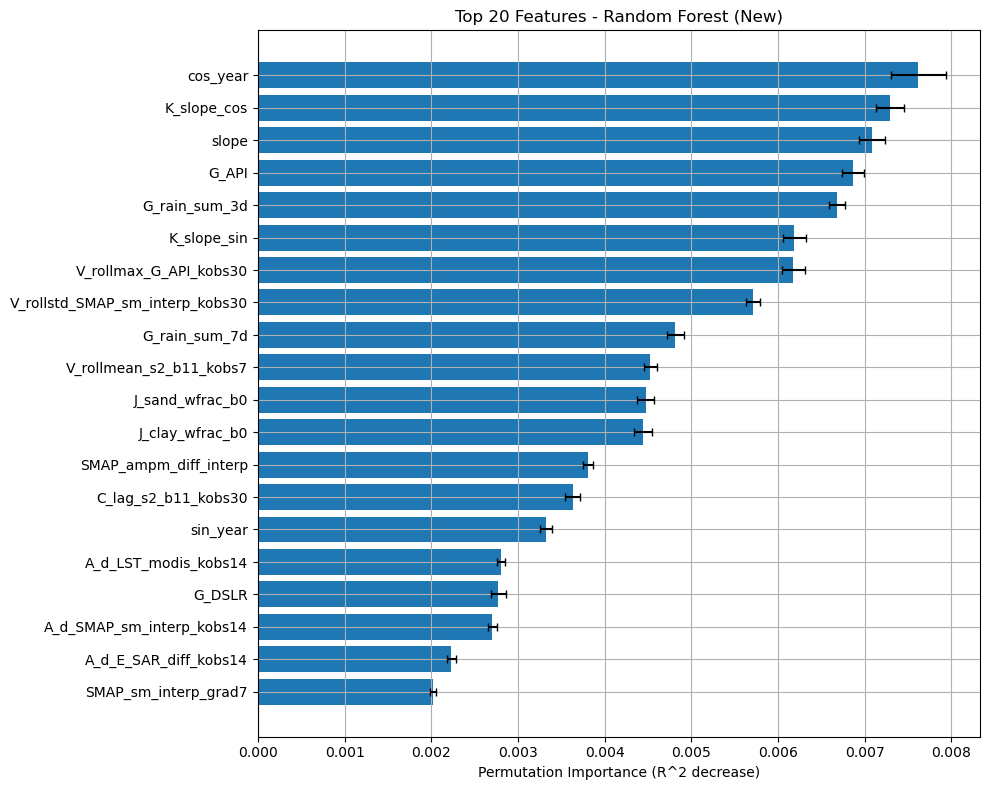

In [20]:
importance_df_combined = pd.DataFrame({
    'feature': FEATURE_COLS,
    'importance': perm_importance_combined.importances_mean,
    'std': perm_importance_combined.importances_std
}).sort_values('importance', ascending=True)

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(importance_df_combined['feature'][:20], importance_df_combined['importance'][:20],
        xerr=importance_df_combined['std'][:20], capsize=3)
ax.set_xlabel('Permutation Importance (R^2 decrease)')
ax.set_title('Top 20 Features - Random Forest (New)')
plt.tight_layout()
plt.show()

In [ ]:
MODEL_DIR = r'/Users/jbalkovec/Desktop/MDR/Models/TemporalSpatial/v1/BEST_MODEL'
MODEL_PKL = MODEL_DIR + "/rf.pkl"

data = {
  'model': rf_drift_combined,
  'features': FEATURE_COLS,
  'weights': w_combined,
}

import joblib
joblib.dump(data, MODEL_PKL)

['/Users/jbalkovec/Desktop/MDR/Models/TemporalSpatial/v1/BEST_MODEL/rf.pkl']

---

_Jakob Balkovec_